[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maxischa/datacamp_test/blob/main/bloc4_ml/cours/seance3_cours.ipynb)

# Séance 4.3 — Arbres de décision — comprendre les variables qui déterminent la prédiction

**Cours** · durée : 2h (≈50 min de cours, ≈50 min d'exercices)

> ⚠️ **Avant de taper quoi que ce soit :** *Fichier → Enregistrer une copie dans Drive*. Sinon votre travail sera perdu en fermant l'onglet.
>
> 📱 Sur tablette, faites d'abord les réglages de [Bien démarrer](https://github.com/maxischa/datacamp_test/blob/main/ressources/setup_tablette.md).

## Objectifs

À la fin de cette séance, vous saurez :

- lire un arbre de décision comme une suite de règles métier
- choisir la profondeur d'un arbre par validation croisée, sans toucher au test
- diagnostiquer le surapprentissage en comparant apprentissage et test
- dire pourquoi l'importance native d'un arbre est biaisée
- mesurer l'importance d'une variable par permutation, sur le jeu de test
- appliquer cette mesure à n'importe quel modèle, arbre ou régression
- montrer le **sens** d'un effet avec une dépendance partielle

## Sommaire du cours

1. **Comprendre pourquoi utiliser un arbre de décision**
   - 1.1 Le problème d'explicabilité des modèles prédictifs
   - 1.2 Définir un arbre de décision
2. **Préparer les données télécoms**
   - 2.1 Importer les bibliothèques et les données
   - 2.2 Nettoyer, encoder et découper les données
3. **Construire et lire un arbre de décision**
   - 3.1 Ajuster un arbre lisible
   - 3.2 Lire la succession des règles
   - 3.3 Comprendre les informations contenues dans un nœud
4. **Choisir la profondeur sans tricher**
   - 4.1 Comprendre le rôle de la profondeur
   - 4.2 Sélectionner une profondeur par validation croisée
   - 4.3 Interpréter les résultats de validation
   - 4.4 Évaluer une seule fois sur le jeu de test
5. **Expliquer les variables qui déterminent la prédiction**
   - 5.1 Mesurer l'importance native de l'arbre
   - 5.2 Mesurer l'importance par permutation
   - 5.3 Comprendre pourquoi les deux classements diffèrent
   - 5.4 Appliquer la permutation à une régression logistique
6. **Déterminer le sens d'un effet**
   - 6.1 Tracer une dépendance partielle
   - 6.2 Confronter le modèle aux taux observés
7. **Visualiser le surapprentissage sur les données télécoms**
   - 7.1 Faire varier la complexité de l'arbre
   - 7.2 Comparer les courbes d'apprentissage et de test
   - 7.3 Diagnostiquer la mémorisation du jeu d'apprentissage
8. **Synthèse**
   - 8.1 Aide-mémoire des commandes
   - 8.2 Les deux mesures d'importance
   - 8.3 Les quatre phrases à retenir
9. **Ressources complémentaires**

## 1. Comprendre pourquoi utiliser un arbre de décision

### 1.1 Le problème d'explicabilité des modèles prédictifs

En séance 4.2, le modèle a désigné 1 073 abonnés à rappeler. En comité, la
question suivante tombe immanquablement :

> *« D'accord. Mais **qu'est-ce qui** fait qu'un client part ? »*

Or, jusqu'à présent, les modèles que nous avons utilisés fournissent des
prédictions dont l'interprétation est parfois difficile d'accès. Mais un modèle
qui prédit sans expliquer ne se déploie pas en entreprise. Personne n'engage un
budget sur une boîte noire. Cette séance a vocation à présenter des solutions à
ce problème d'explicabilité.

La solution en question, c'est l'**arbre de décision**.

### 1.2 Définir un arbre de décision

> Un arbre de décision est un algorithme d'apprentissage, utilisé à la fois
> pour les tâches de classification et de régression. On le représente comme
> une structure hiérarchique et arborescente, qui se compose d'un nœud racine,
> de branches, de nœuds internes et de nœuds feuille.

À titre d'exemple, imaginons que vous essayiez de déterminer si vous devez ou
non aller surfer. Vous pouvez utiliser les règles de décision suivantes pour
faire votre choix :

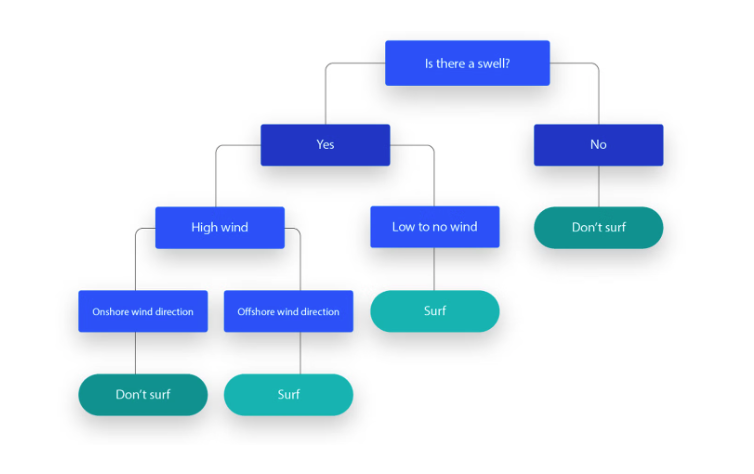

## 2. Préparer les données télécoms

### 2.1 Importer les bibliothèques et les données

Comme à notre habitude, avant de rentrer dans l'explication et son
illustration, on installe les packages utiles et on importe les données.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import accuracy_score, f1_score

# Affichage adapte aux petits ecrans
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 80)

# Les donnees sont lues directement depuis le web : rien a telecharger
BASE = "https://raw.githubusercontent.com/maxischa/datacamp_test/main/bloc4_ml/data/"

### 2.2 Nettoyer, encoder et découper les données

On nettoie ensuite la base de données. On associe le taux de résiliation à un
objet `y` et on convertit l'ensemble des autres valeurs en valeurs numériques.
On divise ensuite les données en données d'entraînement et de test.

In [ ]:
tel = pd.read_csv(BASE + "churn.csv")
tel["total"] = pd.to_numeric(tel["total"], errors="coerce")
tel = tel.dropna(subset=["total"])

y = tel["churn"]
# .astype(float) : les dependances partielles refusent les colonnes
# entieres, et les 0/1 de get_dummies sont des booleens
X = pd.get_dummies(tel.drop(columns=["churn"]), drop_first=True).astype(float)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
print(X.shape[1], "variables")

## 3. Construire et lire un arbre de décision

### 3.1 Ajuster un arbre lisible

L'arbre prend une décision en posant une succession de questions. Pour obtenir
la prédiction d'un client, on commence tout en haut, puis on descend dans
l'arbre en suivant la réponse à chaque question.

La pertinence d'un tel modèle n'est pas sa performance, mais son
intelligibilité. On peut le **lire** facilement.

In [ ]:
arbre = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_tr, y_tr)

# export_text : l'arbre en toutes lettres, une regle par ligne
print(export_text(arbre, feature_names=list(X.columns)))

### 3.2 Lire la succession des règles

L'algorithme pose successivement différentes questions. D'abord : « Le client
a-t-il souscrit un contrat mensuel ? », puis, en fonction de la réponse, il
progresse dans l'arbre représenté ci-dessous :

In [ ]:
plt.figure(figsize=(7, 4))
dessin = plot_tree(arbre, feature_names=list(X.columns), class_names=["reste", "part"],
                   max_depth=2,          ## 2 niveaux : lisible a l'ecran
                   filled=True, impurity=False, fontsize=7)

# On efface la ligne "value" : le detail des effectifs par classe n'apporte
# rien tant qu'on lit l'arbre comme une suite de questions
for boite in dessin:
    boite.set_text("\n".join(ligne for ligne in boite.get_text().split("\n")
                              if not ligne.startswith("value")))
plt.show()

### 3.3 Comprendre les informations contenues dans un nœud

Chaque boîte contient trois choses, et seulement trois : la **question**, le
nombre d'abonnés qui arrivent là (`samples`), et la **réponse** de l'arbre pour
ce groupe (`class`). Les branches de gauche répondent « oui » à la question,
celles de droite « non ».

## 4. Choisir la profondeur sans tricher

### 4.1 Comprendre le rôle de la profondeur

Vous observez que dans le modèle d'arbre de décision, les questions se
succèdent. Il relève de notre décision de choisir jusqu'à quel point l'arbre de
décision croît. Et pour ce faire, on contrôle la « profondeur » de ce dernier.
C'est-à-dire :

> La plus grande distance entre le nœud racine et les nœuds feuilles.

Pourquoi, dans notre exemple précédent, `max_depth=3` ? Simplement par pur
choix arbitraire.

L'enjeu, c'est alors de choisir la profondeur adaptée à notre objectif — en
sachant que plus on augmente la taille de l'arbre, plus précise sera notre
décision ou classification.

### 4.2 Sélectionner une profondeur par validation croisée

Tentation : essayer toutes les profondeurs sur le test et garder la meilleure.
Le problème, c'est le surapprentissage du modèle qui va avec. Pour le
contourner, on utilise la **validation croisée**. Pour ce faire, on découpe le
jeu d'apprentissage en cinq parts égales. Puis on crée cinq modèles qui
diffèrent par leur profondeur. Puis on répète cinq fois : entraîner le modèle
sur quatre parts, mesurer la performance du modèle sur la cinquième, en
s'assurant de faire changer les parts d'entraînement et de test. Chaque unité
de la part de la base de données consacrée à l'apprentissage sert donc **une
fois à mesurer et quatre fois à entraîner**. Ensuite, on retient le modèle qui
obtient les meilleures performances.

Ici, on mesure la performance de nos essais à l'aide de la moyenne du F1 pour
chaque profondeur. Pour rappel, le F1 correspond à un indicateur de performance
composé d'un rapport pondéré entre la précision et le taux de rappel du modèle.
C'est cet indicateur que l'on compare ici entre les différents modèles.

In [ ]:
for profondeur in [2, 3, 4, 5, 8, None]:   ## None = aucune limite
    scores = cross_val_score(
        DecisionTreeClassifier(max_depth=profondeur, random_state=42),
        X_tr, y_tr,          ## sur l'APPRENTISSAGE : le test reste ferme
        cv=5,                ## cinq decoupages successifs
        scoring="f1")        ## le F1 de la seance 4.2
    print(f"profondeur {str(profondeur):<5} F1 moyen {scores.mean():.3f}")

### 4.3 Interpréter les résultats de validation

On peut tirer deux conclusions de cette partie :

- **Sans aucune limite, l'arbre est le plus mauvais** (F1 0,509) alors qu'il
  atteint 0,993 sur ses propres données d'apprentissage. C'est le
  surapprentissage de la séance 4.1, sur un problème de décision cette fois.
- **La profondeur 3, celle que nous venions de lire, est le plus mauvais des
  réglages limités** (0,479). Nous l'avions choisie au hasard, et le hasard a
  mal choisi.

Un troisième point demande plus de prudence : entre les profondeurs 2 (0,586),
4 (0,558) et 5 (0,566), les écarts sont de deux ou trois centièmes. La
**question 13 les comparera à l'écart entre les cinq découpages** — et montrera
qu'ils sont du même ordre. Autrement dit, la validation croisée ne les
départage pas.

Quand une mesure ne tranche pas, on tranche sur autre chose. Ici : un arbre de
profondeur 2 ne pose que deux questions, un peu court pour une note de
service. **Nous retenons 4**, en sachant que 2 aurait été défendable.

In [ ]:
bon = DecisionTreeClassifier(max_depth=4, random_state=42).fit(X_tr, y_tr)
libre = DecisionTreeClassifier(random_state=42).fit(X_tr, y_tr)   ## aucune limite

for nom, m in {"profondeur 4": bon, "sans limite": libre}.items():
    print(f"{nom:<14} justesse {accuracy_score(y_te, m.predict(X_te)):.3f}  "
          f"F1 {f1_score(y_te, m.predict(X_te)):.3f}")

### 4.4 Évaluer une seule fois sur le jeu de test

Le test, lui, n'avait pas été ouvert pour choisir. Il peut donc servir à ce
pour quoi il est fait : **annoncer un chiffre**. F1 de 0,523 pour l'arbre
bridé, 0,501 pour l'arbre libre.

## 5. Expliquer les variables qui déterminent la prédiction

> ⚠️ Deux noms se ressemblent et n'ont rien à voir : **`mensuel`** est le
> *montant de la facture mensuelle*, **`contrat_mensuel`** dit que l'abonné
> n'est *engagé sur aucune durée*. Ils vont tous les deux apparaître.

Jusqu'ici, nous avons vu comment construire un modèle d'arbre de décision,
pourquoi le faire et comment mesurer ses performances. Mais en introduction de
la séance, nous avons insisté sur une des caractéristiques de ces modèles :
l'explicabilité. On cherche donc désormais à comprendre le comportement de
l'arbre de décision pour pouvoir l'expliquer. Pour ce faire, il existe
plusieurs méthodes.

### 5.1 Mesurer l'importance native de l'arbre

Un arbre sait dire, gratuitement, combien chacune de ses coupures l'a fait
progresser. Demandons-le à l'arbre **sans limite**, celui qui a coupé partout.

In [ ]:
# feature_importances_ : le gain cumule de toutes les coupures sur la variable
native = pd.Series(libre.feature_importances_, index=X.columns)

native.sort_values(ascending=False).head(5).round(3)

La facture mensuelle arrive en tête (0,258), suivie de la facture cumulée
(0,237). Le contrat n'est que troisième. Conclusion apparente : **c'est le
montant qui fait partir les clients**.

Gardez cette phrase en tête trente secondes.

### 5.2 Mesurer l'importance par permutation

Principe : on mélange une colonne au hasard — ce qui détruit son information
sans rien changer d'autre — et on regarde **combien le modèle perd**, sur le
jeu de test. Une variable utile fait chuter la performance ; une variable
inutile ne change rien.

In [ ]:
# On melange une colonne et on regarde ce que le modele PERD, en F1
perm = permutation_importance(libre, X_te, y_te,   ## sur le TEST
                              n_repeats=5, random_state=42, scoring="f1")

pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False).head(5).round(4)

**`contrat_mensuel` passe premier**, loin devant (0,148). Les deux factures
reculent.

### 5.3 Comprendre pourquoi les deux classements diffèrent

`feature_importances_` additionne le gain de **toutes les coupures** où la
variable apparaît. Or une variable continue à des milliers de valeurs
distinctes offre des milliers de coupures possibles, et l'arbre s'en ressert à
chaque niveau ; une colonne 0/1 n'offre **qu'une seule** coupure, utilisable
une fois. Le total favorise donc mécaniquement les variables continues,
indépendamment de leur utilité réelle.

La démonstration tient en une ligne, et c'est la question 9 : ajoutez à `X` une
colonne de nombres tirés **au hasard**, sans aucun lien avec le départ. Sur
l'arbre sans limite, elle arrive **première** en importance native.

La permutation mesure autre chose : ce que le modèle **perd** quand on lui
retire l'information, sur des données qu'il n'a jamais vues.

> ⚠️ **Croyez la permutation.** Et remarquez qu'elle confirme le tableau de la
> séance 4.2 : 42,7 % de départs au contrat mensuel contre 2,8 % à deux ans.
> Deux chemins différents, une seule réponse.

### 5.4 Appliquer la permutation à une régression logistique

`feature_importances_` n'existe **que** pour les modèles construits à base
d'arbres. Une régression linéaire ou logistique n'a pas cet attribut du tout.

La permutation, elle, ne demande rien au modèle : juste de savoir prédire. On
mélange une colonne, on redemande une prédiction, on mesure la perte. Ça
fonctionne donc **à l'identique** sur la régression logistique de la séance
4.2 — et sur une régression linéaire, et sur tout ce que vous croiserez
ensuite.

In [ ]:
# Le modele de la seance 4.2, remonte a l'identique
logistique = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logistique.fit(X_tr, y_tr)

pl = permutation_importance(logistique, X_te, y_te,   ## meme fonction, autre modele
                            n_repeats=5, random_state=42, scoring="f1")
pd.Series(pl.importances_mean, index=X.columns).sort_values(ascending=False).head(5).round(4)

**Les mêmes trois variables en tête** — `anc`, `contrat_mensuel`,
`internet_fibre` — obtenues par une famille de modèles qui n'a rien à voir avec
un arbre.

C'est ce qui donne à une recommandation sa solidité : deux méthodes
indépendantes, un même verdict. À l'inverse, une conclusion qui ne tient que
sur un modèle est une conclusion sur ce modèle, pas sur l'entreprise.

## 6. Déterminer le sens d'un effet

### 6.1 Tracer une dépendance partielle

« Le contrat compte » ne se décide pas. Il faut savoir **dans quel sens** et
**de combien**. C'est ce que montre une **dépendance partielle** : on fait
varier une seule variable, tout le reste figé, et on regarde la probabilité
que le modèle prédit.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

# On fait varier anc seule, tout le reste fige : le SENS de l'effet
PartialDependenceDisplay.from_estimator(bon, X_te, ["anc"], ax=ax)
plt.title("Risque de depart predit, selon l'anciennete")
plt.show()

### 6.2 Confronter le modèle aux taux observés

La courbe descend par paliers — c'est un arbre, elle ne peut faire que ça — et
l'essentiel de la descente se joue **sur les premiers mois**.

Vérifions sur les taux réels, ce qui est toujours plus convaincant qu'une
courbe de modèle :

In [ ]:
tranches = pd.cut(tel["anc"], [0, 12, 24, 48, 72])   ## comme au bloc 2

(tel.groupby(tranches, observed=True)["churn"].mean() * 100).round(1)

**47,7 % la première année, 28,7 % la deuxième, 20,4 % entre deux et quatre
ans, 9,5 % au-delà.** Le risque ne disparaît jamais complètement, mais il est
divisé par cinq entre la première et la cinquième année.

Voilà une phrase de note de direction : « l'effort de rétention doit porter en
priorité sur les douze premiers mois, où se concentre près de la moitié des
départs. »

## 7. Visualiser le surapprentissage sur les données télécoms

### 7.1 Faire varier la complexité de l'arbre

Reprenons exactement les abonnés, la cible `churn` et le découpage
apprentissage/test utilisés depuis le début du cours. Nous ne changeons donc ni
de problème ni de base de données : seule la **complexité de l'arbre** varie.

Un arbre plus profond peut créer davantage de feuilles et isoler des groupes de
plus en plus petits. Cette souplesse améliore presque toujours son ajustement
aux données d'apprentissage, mais elle peut finir par capturer des
particularités qui ne se reproduisent pas chez de nouveaux abonnés.

Pour rendre ce phénomène visible, comparons le F1 sur les deux jeux. Le test
est utilisé ici uniquement pour **illustrer après coup** la généralisation ; la
profondeur avait déjà été choisie par validation croisée dans la partie 4.

In [ ]:
profondeurs = [4, 5, 6, 8, 10, 12, None]
resultats_overfit = []

for profondeur in profondeurs:
    modele_complexe = DecisionTreeClassifier(
        max_depth=profondeur, random_state=42).fit(X_tr, y_tr)

    f1_train = f1_score(y_tr, modele_complexe.predict(X_tr))
    f1_test = f1_score(y_te, modele_complexe.predict(X_te))

    resultats_overfit.append({
        "profondeur": "sans limite" if profondeur is None else str(profondeur),
        "feuilles": modele_complexe.tree_.n_leaves,
        "F1 apprentissage": round(f1_train, 3),
        "F1 test": round(f1_test, 3),
        "ecart": round(f1_train - f1_test, 3)})

resultats_overfit = pd.DataFrame(resultats_overfit)
print(resultats_overfit.to_string(index=False))

### 7.2 Comparer les courbes d'apprentissage et de test

Le nombre de feuilles mesure ici la souplesse réelle du modèle. Lorsque la
profondeur augmente, l'arbre découpe les abonnés en groupes toujours plus
fins : **16 feuilles** à la profondeur 4, contre **1 050 feuilles** sans
limite.

Le F1 d'apprentissage s'approche progressivement de 1. En revanche, le F1 de
test ne suit pas cette progression. L'écart entre les deux jeux devient donc le
signal du surapprentissage.

In [ ]:
positions = np.arange(len(resultats_overfit))

plt.figure(figsize=(7, 4))
plt.plot(positions, resultats_overfit["F1 apprentissage"],
         marker="o", linewidth=2.5, color="#2878B5", label="Apprentissage")
plt.plot(positions, resultats_overfit["F1 test"],
         marker="o", linewidth=2.5, color="#D64541", label="Test")
plt.fill_between(positions, resultats_overfit["F1 test"],
                 resultats_overfit["F1 apprentissage"],
                 color="#F2B5B3", alpha=0.35, label="Ecart de generalisation")
plt.xticks(positions, resultats_overfit["profondeur"])
plt.ylim(0.4, 1.03)
plt.xlabel("Profondeur maximale de l'arbre")
plt.ylabel("Score F1")
plt.title("Surapprentissage sur les abonnes telecoms")
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### 7.3 Diagnostiquer la mémorisation du jeu d'apprentissage

Comparons les deux extrêmes utiles :

| Modèle | Feuilles | F1 apprentissage | F1 test | Écart |
|---|---:|---:|---:|---:|
| profondeur 4 | 16 | 0,568 | 0,523 | 0,045 |
| sans limite | 1 050 | 0,993 | 0,501 | 0,492 |

L'arbre sans limite est presque parfait sur les abonnés qu'il connaît, mais il
prédit moins bien les abonnés du test que l'arbre limité. Il n'a pas découvert
une règle plus générale : il a **mémorisé** des particularités du jeu
d'apprentissage.

> ⚠️ **Un excellent score d'apprentissage n'est pas une preuve de qualité.** Le
> surapprentissage se reconnaît à un score d'apprentissage qui continue de
> progresser alors que le score obtenu sur des données nouvelles stagne ou se
> dégrade.

Cette démonstration explique également pourquoi la partie 4 choisissait la
profondeur par validation croisée et ne laissait pas l'arbre grandir librement.

---

## 8. Synthèse

### 8.1 Aide-mémoire des commandes

| Vous voulez... | La commande |
|---|---|
| un arbre lisible | `DecisionTreeClassifier(max_depth=3)` |
| lire ses règles | `print(export_text(a, feature_names=list(X.columns)))` |
| le dessiner | `plot_tree(a, feature_names=..., filled=True, impurity=False)` |
| choisir un réglage sans toucher au test | `cross_val_score(modele, X_tr, y_tr, cv=5, scoring="f1")` |
| l'importance native (biaisée, arbres seulement) | `m.feature_importances_` |
| l'importance honnête, sur **tout** modèle | `permutation_importance(m, X_te, y_te, n_repeats=5, scoring="f1")` |
| le sens de l'effet | `PartialDependenceDisplay.from_estimator(m, X_te, ["anc"])` |

### 8.2 Les deux mesures d'importance

| Mesure | Ce qu'elle vaut | Ses limites |
|---|---|---|
| `feature_importances_` | gratuite, immédiate | n'existe **que** pour les arbres ; calculée sur l'apprentissage ; **favorise les variables à nombreuses valeurs** — ici `mensuel` et `total` |
| permutation | mesurée sur le test, sur la métrique qui vous intéresse, et sur **n'importe quel** modèle | plus lente ; sensible à la métrique choisie |

### 8.3 Les quatre phrases à retenir

1. **Un arbre se lit.** C'est sa vraie force : `export_text` produit des règles
   transposables telles quelles dans une note de service.

2. **L'importance native se laisse berner.** Sur l'arbre sans limite, elle
   classe `mensuel` et `total` en tête ; la permutation met `contrat_mensuel`
   premier — ce que le tableau de la séance 4.2 disait déjà.

3. **Une importance ne donne pas un sens.** « Le contrat compte » ne se décide
   pas ; « le risque de départ se concentre sur la première année » se décide.

4. **Le surapprentissage se voit dans l'écart entre apprentissage et test.**
   Sur les abonnés télécoms, l'arbre sans limite atteint un F1 de 0,993 sur
   l'apprentissage mais seulement 0,501 sur le test.

## 9. Ressources complémentaires

- [« Qu'est-ce qu'un arbre de décision ? », IBM](https://www.ibm.com/fr-fr/think/topics/decision-trees)
- [« Decision Trees in Machine Learning », Dillip Kumar](https://dilipkumar.medium.com/decision-trees-in-machine-learning-cc79b65de96c)